In [1]:
import io
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime as dt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px
from IPython.display import HTML
from IPython.display import Image
import warnings
warnings.filterwarnings('ignore')

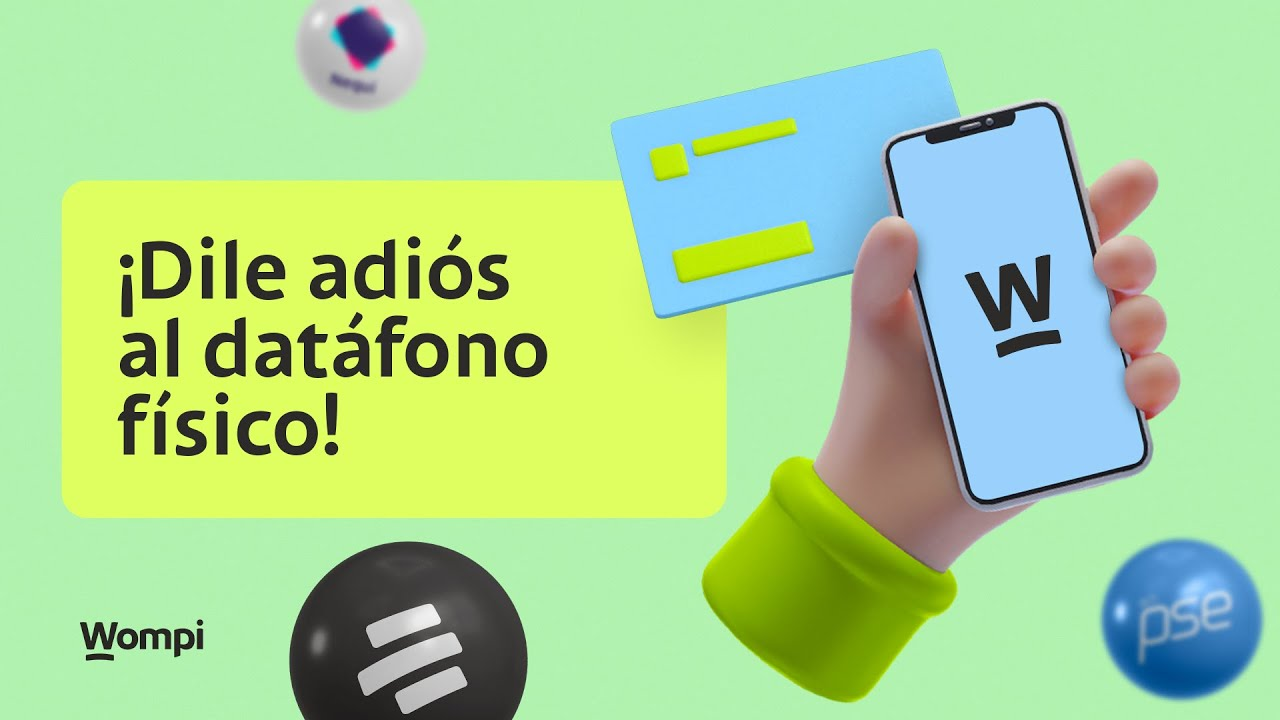

In [2]:
Image(filename = "img/wompi.jpg", width=1500, height=500)

# Introducción

In [5]:
df = pd.read_excel('main_data/evolucion_vinculacion_y_uso_adquirencia_y_wompi_con_duplicados.xlsx', sheet_name='Sheet1', converters={'fecha_ym2': pd.Timestamp})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Unnamed: 0                  47 non-null     int64         
 1   fecha_ym                    47 non-null     int64         
 2   fecha_ym2                   47 non-null     datetime64[ns]
 3   num_vinc_new                47 non-null     int64         
 4   num_vinc_new_cumsum_ym      47 non-null     int64         
 5   num_vinc_new_uso_cumsum_ym  47 non-null     int64         
 6   num_vinc_new_prop_uso       47 non-null     float64       
 7   num_vinc_old                47 non-null     int64         
 8   num_vinc_old_uso_cumsum_ym  47 non-null     int64         
 9   num_vinc_old_prop_uso       47 non-null     float64       
 10  num_vinc_cumsum             47 non-null     int64         
 11  num_vinc_all_uso_cumsum_ym  47 non-null     int64         
 

In [11]:
df

,Unnamed: 0,fecha_ym,fecha_ym2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old,num_vinc_old_uso_cumsum_ym,num_vinc_old_prop_uso,num_vinc_cumsum,num_vinc_all_uso_cumsum_ym,num_vinc_all_prop_uso
0,0,202511,2025-11-01,15051,100796,38823,0.3852,323753,103274,0.3190,424549,142097,0.3347
1,1,202510,2025-10-01,16248,85745,34180,0.3986,323753,102731,0.3173,409498,136911,0.3343
2,2,202509,2025-09-01,22796,69497,29340,0.4222,323753,102090,0.3153,393250,131430,0.3342
3,3,202508,2025-08-01,7078,46701,22020,0.4715,323753,101310,0.3129,370454,123330,0.3329
4,4,202507,2025-07-01,8146,39623,19882,0.5018,323753,100437,0.3102,363376,120319,0.3311
5,5,202506,2025-06-01,6345,31477,15970,0.5074,323753,99408,0.3070,355230,115378,0.3248
6,6,202505,2025-05-01,6469,25132,12905,0.5135,323753,98241,0.3034,348885,111146,0.3186
7,7,202504,2025-04-01,5234,18663,9492,0.5086,323753,96434,0.2979,342416,105926,0.3093
8,8,202503,2025-03-01,4855,13429,6541,0.4871,323753,94424,0.2917,337182,100965,0.2994
9,9,202502,2025-02-01,4466,8574,3989,0.4652,323753,91308,0.2820,332327,95297,0.2868


# Vinculaciones

In [36]:
df_plot1 = df[['fecha_ym2', 'num_vinc_new_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ym2', 'num_vinc_old']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ym2', 'num_vinc_cumsum']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de vinculaciones por clientes nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=140000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=424549,
            text="424.549",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=323753,
            text="323.753",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=100796,
            text="100.796",
            showarrow=True,
            arrowhead=1)
fig.show()

# Uso

In [32]:
df_plot1 = df[['fecha_ym2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ym2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ym2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución clientes recibiendo al menos 1 transacción [año acumulado] nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=50000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=142097,
            text="142.097",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=103274,
            text="103.274",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=38823,
            text="38.823",
            showarrow=True,
            arrowhead=1)
fig.show()

# Proporción uso

In [35]:
df_plot1 = df[['fecha_ym2', 'num_vinc_new_prop_uso']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ym2', 'num_vinc_old_prop_uso']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ym2', 'num_vinc_all_prop_uso']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución proporción de clientes realizando al menos 1 transacción [año acumulado] por nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Proporción de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=0.35,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=0.3347,
            text="0,3347",
            showarrow=False,
            yshift=10)
fig.add_annotation(x='2025-11-01', y=0.319,
            text="0,319",
            showarrow=False,
            yshift=10)
fig.add_annotation(x='2025-11-01', y=0.3852,
            text="0,3852",
            showarrow=False,
            yshift=10)
fig.show()

# Cifras en perspectiva histórica, metas y proyecciones

In [39]:
df_plot1 = df[['fecha_ym2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ym2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ym2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución clientes recibiendo al menos 1 transacción [año acumulado] nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=50000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=142097,
            text="142.097",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2024-12-01', y=140193,
            text="<b>140.193</b>",
            showarrow=True,
            yshift=10,
            arrowhead=5,
            font=dict(
            family="Courier New, monospace",
            size=20,
            color="#E60505"
            ))
fig.add_annotation(x='2025-11-01', y=103274,
            text="103.274",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=38823,
            text="38.823",
            showarrow=True,
            arrowhead=1)
fig.show()

# Proyecciones

No se hace proyección con un modelo para crearla sobre las imagenes cuando se haga la presentación. Es una forma de presentar que deseo explorar, realizar la proyección con la herramienta de lapiz que tienen las herramientas de presentación.

En el futuro se puede crear proyección con modelo heurístico o modelo estadístico.

## Vinculaciones

In [47]:
# Crear periodo de tiempo
index_date = pd.date_range(start='2025-12-01', end='2027-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = 160000
df_periodo_2['tipo_valor'] = 'metal_lineal'
df_data = df[['fecha_ym2', 'num_vinc_new']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot

,fecha,valor,tipo_valor,periodo_2
0,2025-11-01,15051,real,NaN
1,2025-10-01,16248,real,NaN
2,2025-09-01,22796,real,NaN
3,2025-08-01,7078,real,NaN
4,2025-07-01,8146,real,NaN
...,...,...,...,...
67,2027-08-01,160000,metal_lineal,1.0
68,2027-09-01,160000,metal_lineal,1.0
69,2027-10-01,160000,metal_lineal,1.0
70,2027-11-01,160000,metal_lineal,1.0


In [50]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución clientes nuevos vinculados por mes y meta lineal",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes nuevos"
            ))
)
fig.add_annotation(x='2025-06-01', y=120000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2025-12-01', y=162000,
            text="Crecimiento lineal 160.00 clientes nuevos/mes para obtener <b>4 millones en diciembre 2027</b>",
            showarrow=True,
            arrowhead=1)

fig.show()

## Uso

In [53]:
# Crear periodo de tiemp
index_date = pd.date_range(start='2025-12-01', end='2027-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['meta_lineal_1'] = 47556
df_periodo_2['meta_lineal_1'][0] = 47556 + 142097
df_periodo_2['valor'] = df_periodo_2['meta_lineal_1'].cumsum()
df_periodo_2 = df_periodo_2[['fecha', 'valor']]
df_periodo_2['tipo_valor'] = 'metal_lineal'
df_data = df[['fecha_ym2', 'num_vinc_all_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot

,fecha,valor,tipo_valor
0,2025-11-01,142097,real
1,2025-10-01,136911,real
2,2025-09-01,131430,real
3,2025-08-01,123330,real
4,2025-07-01,120319,real
...,...,...,...
67,2027-08-01,1140773,metal_lineal
68,2027-09-01,1188329,metal_lineal
69,2027-10-01,1235885,metal_lineal
70,2027-11-01,1283441,metal_lineal


In [56]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución clientes totales recibiendo al menos 1 transacción [año acumulado] y meta lineal",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=600000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2025-12-01', y=190000,
            text="Crecimiento lineal 47.556 clientes/mes",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2027-12-01', y=1332000,
            text="<b>Meta 5x: 1'331.000 clientes diciembre 2027</b>",
            showarrow=True,
            arrowhead=1)
fig.show()

# Contribución

## Vinculaciones

In [22]:

df_plot3 = df[['fecha_ym2', 'num_vinc_cumsum']]
df_plot3.columns = ['fecha', 'cantidad_clientes']

df_plot = df_plot3

fig = px.line(df_plot, x="fecha", y="cantidad_clientes",markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de vinculaciones por clientes nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=400000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=408348,
            text="408.348",
            showarrow=True,
            arrowhead=1)
fig.show()

In [6]:
df.columns

Index(['Unnamed: 0', 'fecha_ym', 'fecha_ym2', 'num_vinc_new',
       'num_vinc_new_cumsum_ym', 'num_vinc_new_uso_cumsum_ym',
       'num_vinc_new_prop_uso', 'num_vinc_old', 'num_vinc_old_uso_cumsum_ym',
       'num_vinc_old_prop_uso', 'num_vinc_cumsum',
       'num_vinc_all_uso_cumsum_ym', 'num_vinc_all_prop_uso'],
      dtype='object')

In [ ]:
# Selección variable
df_model = df[['fecha_ym2', 'num_vinc_cumsum']]
df_model.columns = ['fecha', 'num_vinc']

# Agregar variables
# Tendencia
df_model['tendencia'] = [i + 1 for i in range(len(df_model))]

# Inicio campana
# index_date = pd.to_datetime(['2025-06-01', '2025-07-01'])
index_date = pd.date_range(start='2025-06-01', end='2025-11-30', freq='MS')
df_campana= pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_campana.columns = ['fecha', 'campana']
df_model = df_model.merge(df_campana, how='left', on='fecha').fillna(0)

df_model

,fecha,num_vinc,tendencia,campana
0,2022-01-01,123989,1,0.0
1,2022-02-01,128393,2,0.0
2,2022-03-01,134153,3,0.0
3,2022-04-01,138651,4,0.0
4,2022-05-01,143962,5,0.0
5,2022-06-01,149766,6,0.0
6,2022-07-01,154876,7,0.0
7,2022-08-01,161179,8,0.0
8,2022-09-01,166934,9,0.0
9,2022-10-01,172869,10,0.0


# Ajustar modelos

Se prueban diferentes longitudes de dataset, es decir se ajusta modelo sobre diferentes periodos de tiempos:

- Desde 20220101 hasta 20250501
- Desde 20230101 hasta 20250501
- Desde 20240101 hasta 20250501
- Desde 20250101 hasta 20250501

Se observa que mientras son más actualizados los datos [menos datos de entrenamiento] disminuye Bayesian Information Criterion [BIC], por tanto se obtienen mejores modelos sin deteriorar fuertemente el R2 ajustado.

Esto se debe a que la variable dependiente crece linealmente sin estacionalidades.

In [55]:
mod = smf.ols(formula="num_vinc ~ tendencia", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               num_vinc   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.411e+05
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           5.17e-71
Time:                        11:43:49   Log-Likelihood:                -343.02
No. Observations:                  41   AIC:                             690.0
Df Residuals:                      39   BIC:                             693.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.185e+05    339.381    349.200      0.0

In [56]:
df_plot1 = df_model[0:41][['fecha', 'num_vinc']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[0:41][['fecha']]
df_plot2['num_vinc'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='vble_dep', markers=True)
fig.show()

In [65]:
df_model_i1 = df_model[12:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
df_model_i1

,fecha,num_vinc,tendencia,campana
12,2023-01-01,187237,1,0.0
13,2023-02-01,191950,2,0.0
14,2023-03-01,197243,3,0.0
15,2023-04-01,201763,4,0.0
16,2023-05-01,207416,5,0.0
17,2023-06-01,212190,6,0.0
18,2023-07-01,218173,7,0.0
19,2023-08-01,223738,8,0.0
20,2023-09-01,229350,9,0.0
21,2023-10-01,234840,10,0.0


In [66]:
mod = smf.ols(formula="num_vinc ~ tendencia", data=df_model_i1)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               num_vinc   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.690e+04
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           2.76e-45
Time:                        11:48:15   Log-Likelihood:                -243.23
No. Observations:                  29   AIC:                             490.5
Df Residuals:                      27   BIC:                             493.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.818e+05    419.781    433.157      0.0

In [67]:
df_plot1 = df_model[:41][['fecha', 'num_vinc']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_vinc'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='vble_dep', markers=True)
fig.show()

In [68]:
df_model_i1 = df_model[24:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_vinc ~ tendencia", data=df_model_i1)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               num_vinc   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.180e+04
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           3.84e-23
Time:                        11:48:44   Log-Likelihood:                -139.71
No. Observations:                  17   AIC:                             283.4
Df Residuals:                      15   BIC:                             285.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.469e+05    484.519    509.660      0.0

In [70]:
df_plot1 = df_model[:41][['fecha', 'num_vinc']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_vinc'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])

fig = px.line(df_plot, x="fecha", y="num_vinc", color='vble_dep', markers=True)
fig.show()

In [71]:
df_model_i1 = df_model[36:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_vinc ~ tendencia", data=df_model_i1)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               num_vinc   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     517.8
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           0.000186
Time:                        11:49:16   Log-Likelihood:                -38.613
No. Observations:                   5   AIC:                             81.23
Df Residuals:                       3   BIC:                             80.44
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    3.08e+05    740.004    416.251      0.0

In [72]:
df_plot1 = df_model[:41][['fecha', 'num_vinc']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_vinc'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])

fig = px.line(df_plot, x="fecha", y="num_vinc", color='vble_dep', markers=True)
fig.show()

## Obtener contrafactual

In [83]:
# Modelo seleccionado
df_model_i1 = df_model[36:41].reset_index(drop=True)
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_vinc ~ tendencia", data=df_model_i1)
res = mod.fit()

In [84]:
df_model_i1

,fecha,num_vinc,tendencia,campana
0,2025-01-01,313674,1,0.0
1,2025-02-01,317970,2,0.0
2,2025-03-01,322701,3,0.0
3,2025-04-01,327805,4,0.0
4,2025-05-01,334142,5,0.0


In [85]:
dict_new_data = {'tendencia': [6,7,8,9,10,11]}
df_model_new_data = pd.DataFrame(dict_new_data)
df_model_new_data

,tendencia
0,6
1,7
2,8
3,9
4,10
5,11


In [86]:
df_model_new_data = pd.concat([df_model_i1[['tendencia']], df_model_new_data])
df_model_new_data = df_model_new_data.reset_index(drop=True)
df_model_new_data

,tendencia
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [87]:
res.fittedvalues

0    313104.2
1    318181.3
2    323258.4
3    328335.5
4    333412.6
dtype: float64

In [ ]:
pred = res.get_prediction(df_model_new_data)
df_pred = pred.summary_frame(alpha=0.05)
df_pred

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,313104.2,546.528883,311364.901175,314843.498825,310263.936913,315944.463087
1,318181.3,386.454279,316951.430007,319411.169993,315621.121451,320741.478549
2,323258.4,315.538598,322254.215355,324262.584645,320798.660013,325718.139987
3,328335.5,386.454279,327105.630007,329565.369993,325775.321451,330895.678549
4,333412.6,546.528883,331673.301175,335151.898825,330572.336913,336252.863087
5,338489.7,740.003606,336134.678259,340844.721741,335235.769853,341743.630147
6,343566.8,946.615793,340554.246066,346579.353934,339809.485107,347324.114893
7,348643.9,1159.362838,344954.290020,352333.509980,344324.738530,352963.061470
8,353721.0,1375.400860,349343.860614,358098.139386,348801.520027,358640.479973
9,358798.1,1593.391813,353727.216112,363868.983888,353252.309036,364343.890964


In [ ]:
df_model_i1

,fecha,num_vinc,tendencia,campana
0,2025-01-01,313674,1,0.0
1,2025-02-01,317970,2,0.0
2,2025-03-01,322701,3,0.0
3,2025-04-01,327805,4,0.0
4,2025-05-01,334142,5,0.0


In [ ]:
df_plot1 = df_model[36:][['fecha', 'num_vinc']]
df_plot1['Valor'] = 'Real'
df_plot1


,fecha,num_vinc,Valor
36,2025-01-01,313674,Real
37,2025-02-01,317970,Real
38,2025-03-01,322701,Real
39,2025-04-01,327805,Real
40,2025-05-01,334142,Real
41,2025-06-01,340333,Real
42,2025-07-01,348209,Real
43,2025-08-01,358830,Real
44,2025-09-01,377185,Real
45,2025-10-01,393365,Real


In [ ]:
df_plot2 = df_model[['fecha']][-6:].reset_index(drop=True)
df_plot2['num_vinc'] = df_pred['mean'][-6:].reset_index(drop=True)
df_plot2['Valor'] = 'Contrafactual'
df_plot2

,fecha,num_vinc,Valor
0,2025-06-01,338489.7,Contrafactual
1,2025-07-01,343566.8,Contrafactual
2,2025-08-01,348643.9,Contrafactual
3,2025-09-01,353721.0,Contrafactual
4,2025-10-01,358798.1,Contrafactual
5,2025-11-01,363875.2,Contrafactual


In [ ]:
df_plot3 = df_model_i1[['fecha']]
df_plot3['num_vinc'] = df_pred['mean'][:-6]
df_plot3['Valor'] = 'Ajustado'
df_plot3

,fecha,num_vinc,Valor
0,2025-01-01,313104.2,Ajustado
1,2025-02-01,318181.3,Ajustado
2,2025-03-01,323258.4,Ajustado
3,2025-04-01,328335.5,Ajustado
4,2025-05-01,333412.6,Ajustado


In [ ]:
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='Valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Contrafactual número de vinculaciones",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha base"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-11-01', y=408348,
            text="408.348",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=363875,
            text="363.875",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-06-01', y=365000,
            text="Inicio estrategia 5X",
            showarrow=False)
fig.show()

In [175]:
df_plot

,fecha,num_vinc,Valor
36,2025-01-01,313674.0,Real
37,2025-02-01,317970.0,Real
38,2025-03-01,322701.0,Real
39,2025-04-01,327805.0,Real
40,2025-05-01,334142.0,Real
41,2025-06-01,340333.0,Real
42,2025-07-01,348209.0,Real
43,2025-08-01,358830.0,Real
44,2025-09-01,377185.0,Real
45,2025-10-01,393365.0,Real


In [ ]:
df_plot_bar = df_plot[df_plot['fecha'] == '2025-11-01']
df_plot_bar

,fecha,num_vinc,Valor
46,2025-11-01,408348.0,Real
5,2025-11-01,363875.2,Contrafactual


In [ ]:
fig = px.bar(df_plot_bar, x='Valor', y='num_vinc', color='Valor', template='simple_white', text_auto=True)
fig.update_layout(
    title={
        'text': "Contrafactual número de vinculaciones",
        'xanchor': 'left',
        'yanchor': 'top'},
    yaxis=dict(
            title=dict(
                text="Número de clientes vinculados"
            ))
)
fig.show()

In [ ]:
df_resumen_wide = df_plot.pivot(index='fecha', columns='Valor', values='num_vinc')
df_resumen_wide = df_resumen_wide.reset_index()
df_resumen_wide['contribucion_banco'] = df_resumen_wide['Real'] - df_resumen_wide['Predecido']
df_resumen_wide['efecto_prop_banco'] = df_resumen_wide['contribucion_banco'] / df_resumen_wide['Predecido']
df_resumen_wide

Valor,fecha,Ajustado,Predecido,Real,contribucion_banco,efecto_prop_banco
0,2025-01-01,313104.2,NaN,313674.0,NaN,NaN
1,2025-02-01,318181.3,NaN,317970.0,NaN,NaN
2,2025-03-01,323258.4,NaN,322701.0,NaN,NaN
3,2025-04-01,328335.5,NaN,327805.0,NaN,NaN
4,2025-05-01,333412.6,NaN,334142.0,NaN,NaN
5,2025-06-01,NaN,338489.7,340333.0,1843.3,0.005446
6,2025-07-01,NaN,343566.8,348209.0,4642.2,0.013512
7,2025-08-01,NaN,348643.9,358830.0,10186.1,0.029216
8,2025-09-01,NaN,353721.0,377185.0,23464.0,0.066335
9,2025-10-01,NaN,358798.1,393365.0,34566.9,0.096341


In [ ]:
df_resumen_wide.to_excel('main_data/contrafactual_num_vinculaciones.xlsx', index=False)

## Uso

In [182]:
df.columns

Index(['Unnamed: 0', 'fecha_ym', 'fecha_ym2', 'num_vinc_new',
       'num_vinc_new_cumsum_ym', 'num_vinc_new_uso_cumsum_ym',
       'num_vinc_new_prop_uso', 'num_vinc_old', 'num_vinc_old_uso_cumsum_ym',
       'num_vinc_old_prop_uso', 'num_vinc_cumsum',
       'num_vinc_all_uso_cumsum_ym', 'num_vinc_all_prop_uso'],
      dtype='object')

In [ ]:

df_plot3 = df[['fecha_ym2', 'num_vinc_new_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']

df_plot = df_plot3

fig = px.line(df_plot, x="fecha", y="cantidad_clientes",markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución uso clientes nuevos",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=40000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=37253,
            text="37.253",
            showarrow=True,
            arrowhead=1)
fig.show()

In [198]:
# Selección variable
df_model = df[['fecha_ym2', 'num_vinc_new_uso_cumsum_ym']]
df_model.columns = ['fecha', 'num_uso']

# Agregar variables
# Tendencia
df_model['tendencia'] = [i + 1 for i in range(len(df_model))]

# Inicio campana
# index_date = pd.to_datetime(['2025-06-01', '2025-07-01'])
index_date = pd.date_range(start='2025-06-01', end='2025-11-30', freq='MS')
df_campana= pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_campana.columns = ['fecha', 'campana']
df_model = df_model.merge(df_campana, how='left', on='fecha').fillna(0)

# Meses
df_model['meses'] = df_model.fecha.apply(lambda x: x.month)

# Year
df_model['year'] = df_model.fecha.apply(lambda x: x.year)

# Meses dummies
df_meses_dummies = pd.get_dummies(df_model['meses'], dtype=float, drop_first=True, prefix='mes')
df_model = pd.concat([df_model, df_meses_dummies], axis=1)
df_model

,fecha,num_uso,tendencia,campana,meses,year,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
0,2022-01-01,1778,1,0.0,1,2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-01,4978,2,0.0,2,2022,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-03-01,9245,3,0.0,3,2022,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-04-01,12985,4,0.0,4,2022,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-05-01,16995,5,0.0,5,2022,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2022-06-01,21596,6,0.0,6,2022,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2022-07-01,25640,7,0.0,7,2022,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,2022-08-01,30401,8,0.0,8,2022,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,2022-09-01,35168,9,0.0,9,2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,2022-10-01,39844,10,0.0,10,2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Ajustar modelos

In [201]:
mod = smf.ols(formula="num_uso ~ tendencia", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.022
Method:                 Least Squares   F-statistic:                    0.1386
Date:                Wed, 17 Dec 2025   Prob (F-statistic):              0.712
Time:                        10:40:05   Log-Likelihood:                -449.00
No. Observations:                  41   AIC:                             902.0
Df Residuals:                      39   BIC:                             905.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    2.21e+04   4501.337      4.909      0.0

In [202]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [203]:
mod = smf.ols(formula="num_uso ~ tendencia + year", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     958.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.06e-33
Time:                        10:40:57   Log-Likelihood:                -368.30
No. Observations:                  41   AIC:                             742.6
Df Residuals:                      38   BIC:                             747.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   9.589e+07   2.19e+06     43.710      0.0

In [204]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [205]:
mod = smf.ols(formula="num_uso ~ tendencia + year + meses", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     958.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.06e-33
Time:                        10:43:23   Log-Likelihood:                -368.30
No. Observations:                  41   AIC:                             742.6
Df Residuals:                      38   BIC:                             747.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1692      0.004     43.601      0.0

In [206]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [207]:
mod = smf.ols(formula="num_uso ~ tendencia + meses", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     958.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.06e-33
Time:                        10:45:05   Log-Likelihood:                -368.30
No. Observations:                  41   AIC:                             742.6
Df Residuals:                      38   BIC:                             747.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -111.5452    814.858     -0.137      0.8

In [208]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [220]:
mod = smf.ols(formula="num_uso ~ tendencia + mes_2 + mes_3 + mes_4 + mes_5 + mes_6 + mes_7 + mes_8 + mes_9 + mes_10 + mes_11 + mes_12", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     129.8
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.06e-21
Time:                        10:52:26   Log-Likelihood:                -366.32
No. Observations:                  41   AIC:                             758.6
Df Residuals:                      28   BIC:                             780.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4891.6207   1245.999      3.926      0.0

In [221]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [233]:
df_model_i1 = df_model[12:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_uso ~ tendencia + year", data=df_model_i1)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     770.7
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           7.19e-24
Time:                        10:57:19   Log-Likelihood:                -256.46
No. Observations:                  29   AIC:                             518.9
Df Residuals:                      26   BIC:                             523.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   9.106e+07   2.32e+06     39.244      0.0

In [234]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [240]:
df_model_i1 = df_model[24:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_uso ~ tendencia + year", data=df_model_i1)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     3400.
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           1.55e-19
Time:                        11:06:31   Log-Likelihood:                -130.09
No. Observations:                  17   AIC:                             266.2
Df Residuals:                      14   BIC:                             268.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   8.112e+07   9.87e+05     82.147      0.0

In [241]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

# Obtener contrafactual

In [242]:
# Modelo seleccionado
df_model_i1 = df_model[24:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_uso ~ tendencia + year", data=df_model_i1)
res = mod.fit()

In [243]:
df_model_i1

,fecha,num_uso,tendencia,campana,meses,year,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
24,2024-01-01,2221,1,0.0,1,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,2024-02-01,5779,2,0.0,2,2024,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,2024-03-01,9282,3,0.0,3,2024,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,2024-04-01,12131,4,0.0,4,2024,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28,2024-05-01,15160,5,0.0,5,2024,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,2024-06-01,17724,6,0.0,6,2024,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
30,2024-07-01,20987,7,0.0,7,2024,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
31,2024-08-01,24050,8,0.0,8,2024,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32,2024-09-01,27744,9,0.0,9,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
33,2024-10-01,31092,10,0.0,10,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [247]:
dict_new_data = {'tendencia': [18,19,20,21,22,23],
                 'year': [2025 for i in range(6)]}
df_model_new_data = pd.DataFrame(dict_new_data)
df_model_new_data

,tendencia,year
0,18,2025
1,19,2025
2,20,2025
3,21,2025
4,22,2025
5,23,2025


In [248]:
df_model_new_data = pd.concat([df_model_i1[['tendencia', 'year']], df_model_new_data])
df_model_new_data = df_model_new_data.reset_index(drop=True)
df_model_new_data

,tendencia,year
0,1,2024
1,2,2024
2,3,2024
3,4,2024
4,5,2024
5,6,2024
6,7,2024
7,8,2024
8,9,2024
9,10,2024


In [249]:
res.fittedvalues

24     2540.983660
25     5691.441176
26     8841.898693
27    11992.356209
28    15142.813726
29    18293.271242
30    21443.728758
31    24594.186275
32    27744.643791
33    30895.101307
34    34045.558824
35    37196.016340
36      268.284967
37     3418.742484
38     6569.200000
39     9719.657516
40    12870.115033
dtype: float64

In [250]:
pred = res.get_prediction(df_model_new_data)
df_pred = pred.summary_frame(alpha=0.05)
df_pred

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,2540.983660,297.609886,1902.673938,3179.293382,1178.205179,3903.762141
1,5691.441176,260.717448,5132.257866,6250.624487,4363.882567,7018.999786
2,8841.898693,226.925411,8355.192093,9328.605293,7543.203501,10140.593885
3,11992.356209,197.828987,11568.055232,12416.657186,10715.736765,13268.975654
4,15142.813726,175.775668,14765.812414,15519.815037,13881.126016,16404.501435
5,18293.271242,163.638241,17942.302121,18644.240362,17039.116064,19547.426420
6,21443.728758,163.638241,21092.759638,21794.697878,20189.573580,22697.883936
7,24594.186275,175.775667,24217.184963,24971.187586,23332.498565,25855.873984
8,27744.643791,197.828987,27320.342814,28168.944768,26468.024346,29021.263235
9,30895.101307,226.925411,30408.394707,31381.807907,29596.406115,32193.796499


In [251]:
df_model_i1

,fecha,num_uso,tendencia,campana,meses,year,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
24,2024-01-01,2221,1,0.0,1,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,2024-02-01,5779,2,0.0,2,2024,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,2024-03-01,9282,3,0.0,3,2024,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,2024-04-01,12131,4,0.0,4,2024,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28,2024-05-01,15160,5,0.0,5,2024,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,2024-06-01,17724,6,0.0,6,2024,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
30,2024-07-01,20987,7,0.0,7,2024,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
31,2024-08-01,24050,8,0.0,8,2024,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32,2024-09-01,27744,9,0.0,9,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
33,2024-10-01,31092,10,0.0,10,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [268]:
df_plot1 = df_model[24:][['fecha', 'num_uso']]
df_plot1['Valor'] = 'Real'
df_plot1

,fecha,num_uso,Valor
24,2024-01-01,2221,Real
25,2024-02-01,5779,Real
26,2024-03-01,9282,Real
27,2024-04-01,12131,Real
28,2024-05-01,15160,Real
29,2024-06-01,17724,Real
30,2024-07-01,20987,Real
31,2024-08-01,24050,Real
32,2024-09-01,27744,Real
33,2024-10-01,31092,Real


In [269]:
df_plot2 = df_model[['fecha']][-6:].reset_index(drop=True)
df_plot2['num_uso'] = df_pred['mean'][-6:].reset_index(drop=True)
df_plot2['Valor'] = 'Contrafactual'
df_plot2

,fecha,num_uso,Valor
0,2025-06-01,16020.572549,Contrafactual
1,2025-07-01,19171.030065,Contrafactual
2,2025-08-01,22321.487582,Contrafactual
3,2025-09-01,25471.945098,Contrafactual
4,2025-10-01,28622.402614,Contrafactual
5,2025-11-01,31772.860131,Contrafactual


In [270]:
df_plot3 = df_model_i1[['fecha']].reset_index(drop=True)
df_plot3['num_uso'] = df_pred['mean'][:-6]
df_plot3['Valor'] = 'Ajustado'
df_plot3

,fecha,num_uso,Valor
0,2024-01-01,2540.983660,Ajustado
1,2024-02-01,5691.441176,Ajustado
2,2024-03-01,8841.898693,Ajustado
3,2024-04-01,11992.356209,Ajustado
4,2024-05-01,15142.813726,Ajustado
5,2024-06-01,18293.271242,Ajustado
6,2024-07-01,21443.728758,Ajustado
7,2024-08-01,24594.186275,Ajustado
8,2024-09-01,27744.643791,Ajustado
9,2024-10-01,30895.101307,Ajustado


In [288]:
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])
df_plot

,fecha,num_uso,Valor
24,2024-01-01,2221.000000,Real
25,2024-02-01,5779.000000,Real
26,2024-03-01,9282.000000,Real
27,2024-04-01,12131.000000,Real
28,2024-05-01,15160.000000,Real
29,2024-06-01,17724.000000,Real
30,2024-07-01,20987.000000,Real
31,2024-08-01,24050.000000,Real
32,2024-09-01,27744.000000,Real
33,2024-10-01,31092.000000,Real


In [298]:
fig = px.line(df_plot, x="fecha", y="num_uso", color='Valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Contrafactual número de clientes con uso",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-11-01', y=37253,
            text="37.253",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=31772,
            text="31.772",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-06-01', y=30000,
            text="Inicio estrategia 5X",
            showarrow=False)
fig.show()

In [290]:
df_plot_bar = df_plot[df_plot['fecha'] == '2025-11-01']
df_plot_bar['num_uso'] = df_plot_bar.num_uso.round(0)
df_plot_bar



,fecha,num_uso,Valor
46,2025-11-01,37253.0,Real
5,2025-11-01,31773.0,Contrafactual


In [297]:
fig = px.bar(df_plot_bar, x='Valor', y='num_uso', color='Valor', template='simple_white', text_auto=True)
fig.update_layout(
    title={
        'text': "Contrafactual número de clientes con uso",
        'xanchor': 'left',
        'yanchor': 'top'},
    yaxis=dict(
            title=dict(
                text="Número de clientes con uso"
            ))
)
fig.show()



In [292]:
df_plot

,fecha,num_uso,Valor
24,2024-01-01,2221.000000,Real
25,2024-02-01,5779.000000,Real
26,2024-03-01,9282.000000,Real
27,2024-04-01,12131.000000,Real
28,2024-05-01,15160.000000,Real
29,2024-06-01,17724.000000,Real
30,2024-07-01,20987.000000,Real
31,2024-08-01,24050.000000,Real
32,2024-09-01,27744.000000,Real
33,2024-10-01,31092.000000,Real


In [294]:
df_resumen_wide = df_plot.pivot(index='fecha', columns='Valor', values='num_uso')
df_resumen_wide = df_resumen_wide.reset_index()
df_resumen_wide['contribucion_banco'] = df_resumen_wide['Real'] - df_resumen_wide['Contrafactual']
df_resumen_wide['efecto_prop_banco'] = df_resumen_wide['contribucion_banco'] / df_resumen_wide['Contrafactual']
df_resumen_wide



Valor,fecha,Ajustado,Contrafactual,Real,contribucion_banco,efecto_prop_banco
0,2024-01-01,2540.983660,NaN,2221.0,NaN,NaN
1,2024-02-01,5691.441176,NaN,5779.0,NaN,NaN
2,2024-03-01,8841.898693,NaN,9282.0,NaN,NaN
3,2024-04-01,11992.356209,NaN,12131.0,NaN,NaN
4,2024-05-01,15142.813726,NaN,15160.0,NaN,NaN
5,2024-06-01,18293.271242,NaN,17724.0,NaN,NaN
6,2024-07-01,21443.728758,NaN,20987.0,NaN,NaN
7,2024-08-01,24594.186275,NaN,24050.0,NaN,NaN
8,2024-09-01,27744.643791,NaN,27744.0,NaN,NaN
9,2024-10-01,30895.101307,NaN,31092.0,NaN,NaN


In [ ]:
df_resumen_wide.to_excel('main_data/contrafactual_num_clientes_con_uso.xlsx', index=False)